# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hassan9039/intern1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question:

Can search-performance signals identify content that should be prioritized for refresh review?

Decision supported:

The analysis supports prioritizing content for review by ranking pages that show weaker search performance, while treating the output as decision-support rather than proof that a page needs to be refreshed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data source:

FlyRank internship warehouse, build v20260703.

Table used:

fact_content_daily_performance.

Date windows:

March 2026 was used as the feature window and April 2026 was used as the future label window. March features were kept separate from April outcomes to avoid using future information as model inputs.

The analysis uses search-performance fields including GSC impressions, GSC clicks, and average search position. Rows without GSC data availability were excluded from the scoring analysis. Client names, domains, private queries, credentials, and raw client-level exports are not included in the public analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The analysis uses aggregated March 2026 search-performance data at the client-content level.

Features:
- GSC impressions
- GSC clicks
- CTR
- Average search position

Label:
A content item is labeled positive when its April 2026 CTR improves by at least 20% relative to March 2026, subject to sufficient search volume in both months.

Baseline:
A simple rank-based baseline prioritizes content using low CTR and weak average search position, following the same signals used in the W04 baseline.

Validation:
A client-grouped validation split is used so that content from the same client does not appear in both training and test sets.

Leakage control:
March 2026 features are used to predict April 2026 outcomes. April performance is used only to construct the label and is excluded from the model features. Client and content identifiers are used only for grouping and context.

In [6]:
import duckdb
from google.colab import userdata
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

token = userdata.get("HF_TOKEN")
con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{token}'
)
""")

march = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

april = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet'
)"""

features = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS gsc_impressions,
    SUM(gsc_clicks) AS gsc_clicks,
    AVG(NULLIF(gsc_avg_position, 0)) AS gsc_avg_position
FROM {march}
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
""").df()

features["ctr"] = features["gsc_clicks"] / features["gsc_impressions"].replace(0, pd.NA)

future = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS future_impressions,
    SUM(gsc_clicks) AS future_clicks
FROM {april}
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
""").df()

future["future_ctr"] = future["future_clicks"] / future["future_impressions"].replace(0, pd.NA)

model_data = features.merge(
    future,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_data["label"] = (
    (model_data["gsc_impressions"] >= 100) &
    (model_data["future_impressions"] >= 100) &
    (model_data["future_ctr"] >= model_data["ctr"] * 1.20)
).astype(int)

model_data = model_data.dropna(
    subset=["gsc_impressions", "gsc_clicks", "gsc_avg_position", "ctr", "label"]
)

X = model_data[
    ["gsc_impressions", "gsc_clicks", "gsc_avg_position", "ctr"]
]

y = model_data["label"]
groups = model_data["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Model rows:", len(model_data))
print("Positive labels:", y.sum())
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())
print("Overlapping clients:", len(
    set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model rows: 157790
Positive labels: 42003
Training rows: 136739
Test rows: 21051
Training clients: 36
Test clients: 10
Overlapping clients: 0


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

model_prob = model.predict_proba(X_test)[:, 1]

baseline_score = (
    (1 - X_test["ctr"].rank(pct=True)) +
    X_test["gsc_avg_position"].rank(pct=True)
)

results = pd.DataFrame({
    "method": ["Baseline", "Logistic Regression"],
    "roc_auc": [
        roc_auc_score(y_test, baseline_score),
        roc_auc_score(y_test, model_prob)
    ],
    "average_precision": [
        average_precision_score(y_test, baseline_score),
        average_precision_score(y_test, model_prob)
    ]
})

results

,method,roc_auc,average_precision
0,Baseline,0.651928,0.341589
1,Logistic Regression,0.739809,0.487480


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The logistic regression model outperformed the W04 baseline on the same client-grouped test split.

| Method | ROC AUC | Average Precision |
|---|---:|---:|
| Baseline | 0.652 | 0.342 |
| Logistic Regression | 0.740 | 0.487 |

The model showed stronger ranking performance on both evaluation metrics. The results indicate that the combined search-performance features provide useful predictive signal for identifying content whose CTR improves in the following month. This is measured predictive performance and should be treated as decision-support rather than evidence that refreshing content causes the improvement.

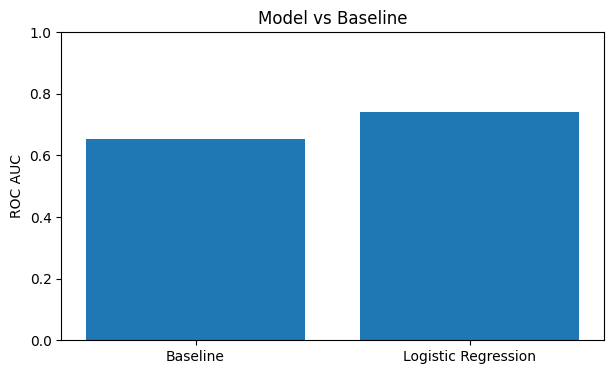

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(results["method"], results["roc_auc"])
plt.ylabel("ROC AUC")
plt.title("Model vs Baseline")
plt.ylim(0, 1)
plt.show()

## 5. Limitations

*What this work cannot claim.*

This analysis has several limitations.

The label measures next-month CTR improvement and does not establish that a content refresh caused the improvement.

The model uses a limited set of GSC search-performance signals and does not include content quality, search intent, technical SEO, or editorial information.

The validation split is client-grouped rather than a fully time-forward evaluation, so performance may differ on future unseen data.

The results are predictive and directional. The ranked outputs should be used to prioritize human review, not as proof that a page requires a refresh or that refreshing it will improve performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model can be used as a prioritization layer for content review.

1. Prioritize pages with the highest predicted probability of next-month CTR improvement.
2. Review high-priority pages alongside their current CTR, impressions, and average position.
3. Use REVIEW_REFRESH for pages with strong predicted opportunity and sufficient search volume.
4. Use MONITOR for lower-confidence pages rather than forcing an intervention.
5. Treat every recommendation as a review queue, with the final refresh decision made through human evaluation.

In [9]:
recommendations = X_test.copy()
recommendations["predicted_probability"] = model_prob
recommendations["action"] = recommendations["predicted_probability"].apply(
    lambda x: "REVIEW_REFRESH" if x >= 0.5 else "MONITOR"
)

recommendations = recommendations.sort_values(
    "predicted_probability",
    ascending=False
)

recommendations.head(10)

,gsc_impressions,gsc_clicks,gsc_avg_position,ctr,predicted_probability,action
14676,91391.0,46.0,27.355006,0.000503,0.947847,REVIEW_REFRESH
108160,73862.0,28.0,7.399241,0.000379,0.917617,REVIEW_REFRESH
3547,91388.0,85.0,20.839925,0.000930,0.898876,REVIEW_REFRESH
82666,61071.0,34.0,34.712403,0.000557,0.824156,REVIEW_REFRESH
3420,60164.0,32.0,34.136038,0.000532,0.823338,REVIEW_REFRESH
29024,53230.0,17.0,35.384263,0.000319,0.813944,REVIEW_REFRESH
82658,48309.0,29.0,6.813802,0.000600,0.745060,REVIEW_REFRESH
29757,44650.0,38.0,32.419128,0.000851,0.648016,REVIEW_REFRESH
94853,29425.0,5.0,28.247270,0.000170,0.628985,REVIEW_REFRESH
82389,24259.0,1.0,2.784944,0.000041,0.608175,REVIEW_REFRESH


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper will include the model-versus-baseline evaluation table and the ROC AUC comparison chart generated above.

The ranked recommendation table contains the highest-priority content opportunities from the held-out test set. Client and content identifiers are retained only for internal reproducibility and are not exposed in the public paper.

In [10]:
import os

os.makedirs("work/outputs", exist_ok=True)

recommendations.to_csv(
    "work/outputs/capstone_ranked_recommendations.csv",
    index=False
)

print("Saved:", "work/outputs/capstone_ranked_recommendations.csv")

Saved: work/outputs/capstone_ranked_recommendations.csv


### 5-Minute Demo Outline

1. Research question and refresh-prioritization decision.
2. March-to-April search-performance dataset and label.
3. Client-grouped validation and leakage controls.
4. Baseline versus logistic regression results.
5. Ranked recommendations and limitations.

### Social-Post Cut

Built a content opportunity scoring analysis using FlyRank search-performance data. A logistic regression model outperformed a simple baseline, achieving 0.740 ROC AUC versus 0.652 on a client-grouped test split. The result is a decision-support workflow for prioritizing content review, not a causal claim about SEO or content refreshes.

### Employer-Facing Summary

I built a reproducible content opportunity scoring workflow using real search-performance data. I compared a logistic regression model against a baseline using client-grouped validation and achieved 0.740 ROC AUC versus 0.652 for the baseline. The workflow produces ranked recommendations while explicitly controlling for leakage and separating predictive evidence from causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
